In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ising_model import ising_hamiltonian_fixed_sz, ising_hamiltonian
from xy_model import xy_hamiltonian_fixed_sz, xy_hamiltonian

In [61]:
# Parameters
N = 6         # Number of spins
J = 1.0       # Coupling constant
h = 0.0       # Transverse field

# Build Hamiltonian
H = ising_hamiltonian(N, J, h, open_bc=False)

# Diagonalize
eigvals, eigvecs = np.linalg.eigh(H)

print("Eigenvalues (energies):")
print(eigvals)

Eigenvalues (energies):
[-6. -6. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2.
 -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2. -2.  2.  2.  2.  2.
  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.
  2.  2.  2.  2.  2.  2.  2.  2.  6.  6.]


Energy: 3.0


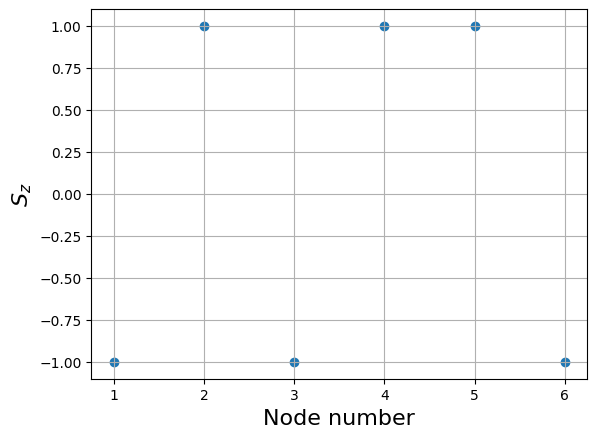

In [42]:
node_number = 56

print(f"Energy: {eigvals[node_number]}")
index_to_state = {i: np.array([1 if bit == '1' else -1 for bit in bin(i)[2:].zfill(N)]) for i in range(2**N)}
plt.scatter(np.arange(1, N + 1, 1), index_to_state[np.argmax(eigvecs[:, node_number])])
fontsize = 16
plt.ylabel(f"$S_z$", fontsize=fontsize)
plt.xlabel("Node number", fontsize=fontsize)
plt.grid()

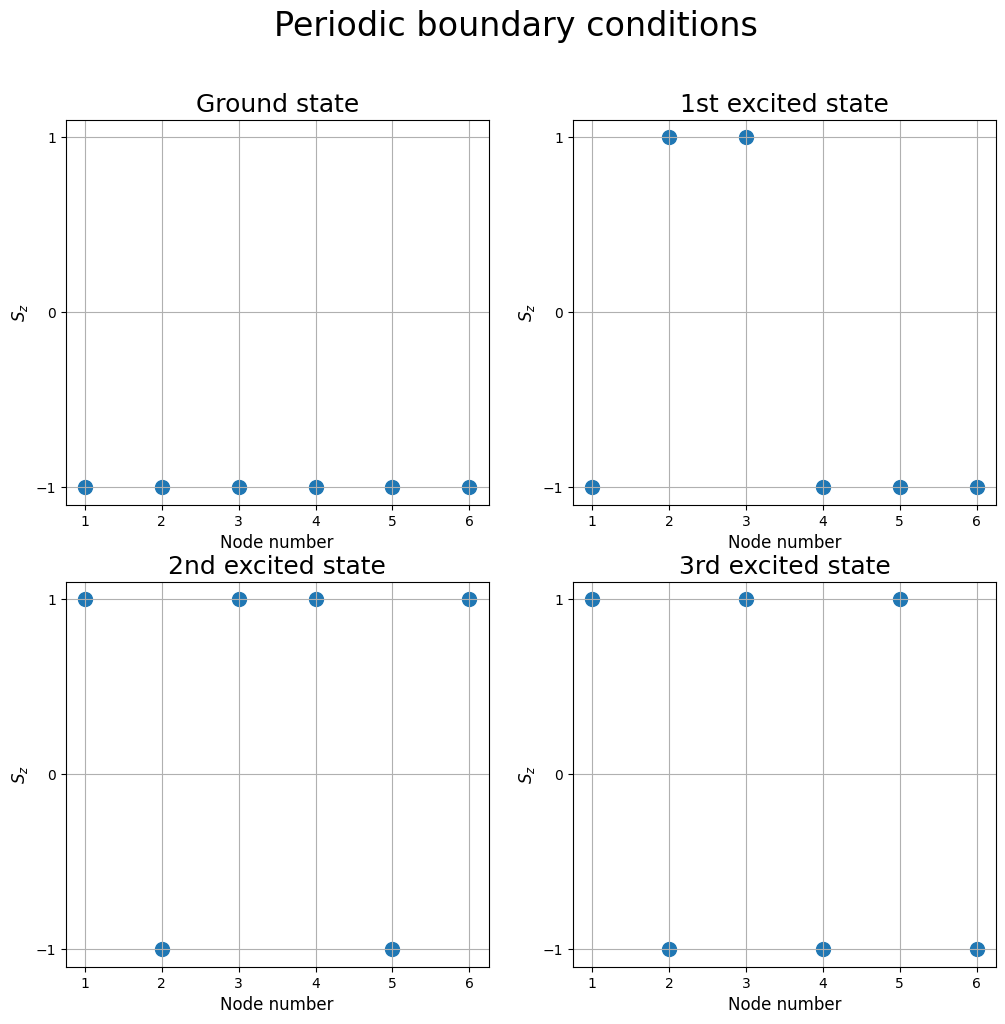

In [58]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 11))
nodes = [0, 12, 44, 63]
titles = ["Ground state", "1st excited state", "2nd excited state", 
          "3rd excited state", "4th excited state", "5th excited state", "6th excited state"]
for axs, node, title in zip(ax.ravel(), nodes, titles):
    index_to_state = {i: np.array([1 if bit == '1' else -1 for bit in bin(i)[2:].zfill(N)]) for i in range(2**N)}
    axs.scatter(np.arange(1, N + 1, 1), index_to_state[np.argmax(eigvecs[:, node])], s=100)
    fontsize = 12
    axs.set_xlabel("Node number", fontsize=fontsize)
    axs.set_ylabel(f"$S_z$", fontsize=fontsize)
    axs.set_title(f"{title}", fontsize=int(fontsize * 1.5))
    axs.set_ylim(-1.1, 1.1)
    axs.set_yticks([-1, 0, 1])
    axs.grid()
fig.suptitle("Periodic boundary conditions", fontsize=fontsize*2);

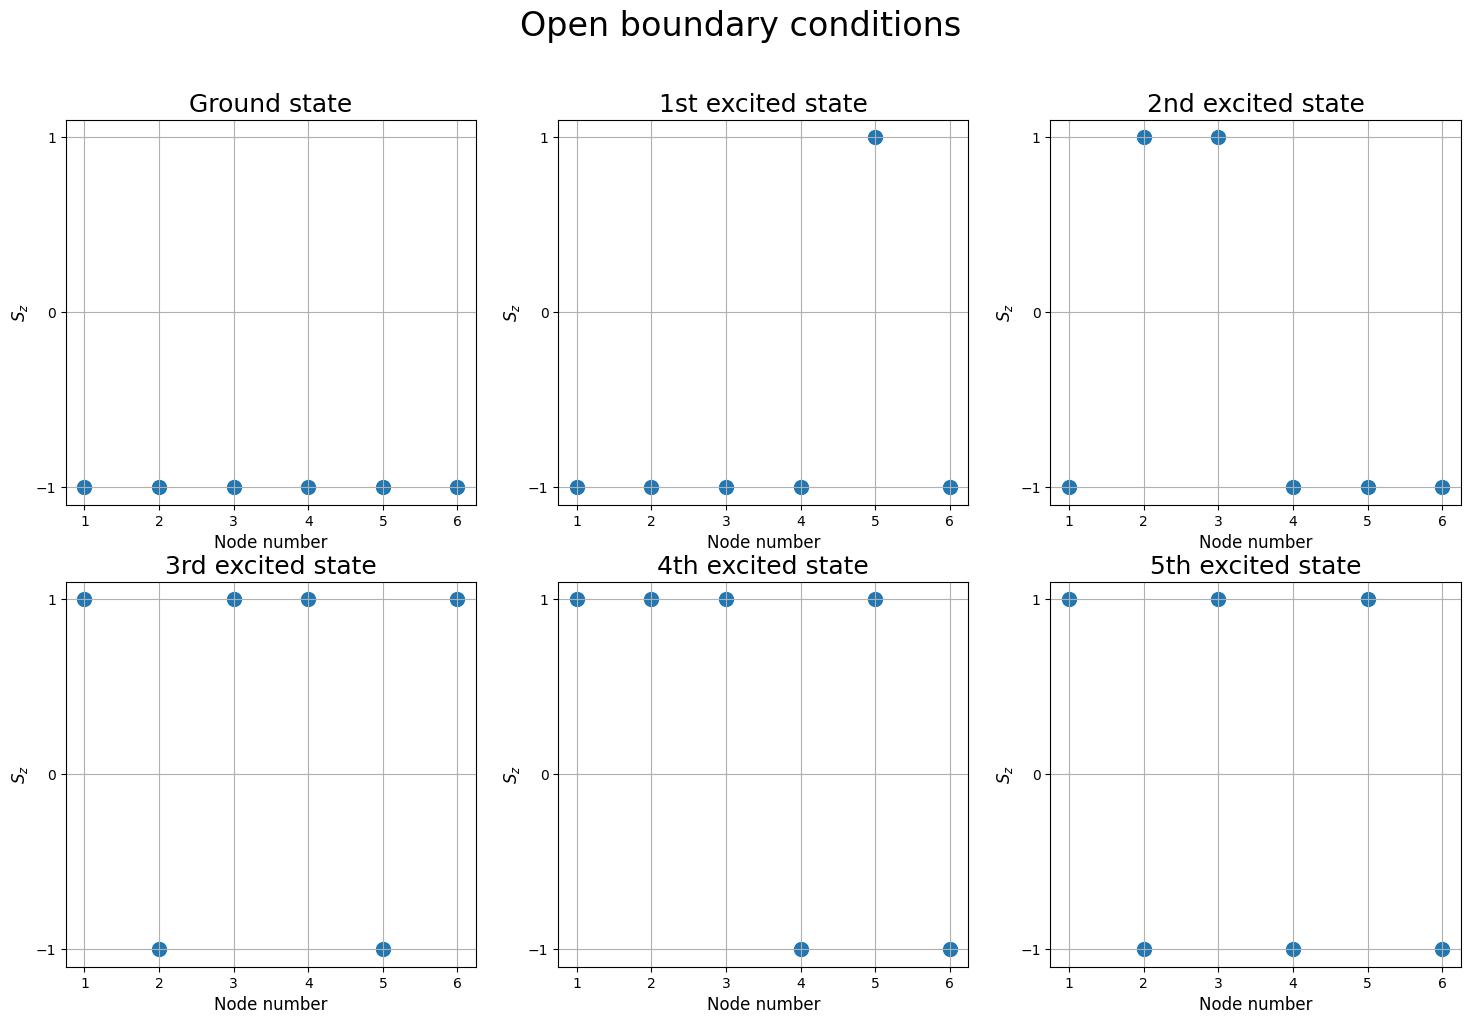

In [62]:
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(18, 11))
nodes = [0, 2, 12, 44, 56, 63]
titles = ["Ground state", "1st excited state", "2nd excited state", 
          "3rd excited state", "4th excited state", "5th excited state", "6th excited state"]
for axs, node, title in zip(ax.ravel(), nodes, titles):
    index_to_state = {i: np.array([1 if bit == '1' else -1 for bit in bin(i)[2:].zfill(N)]) for i in range(2**N)}
    axs.scatter(np.arange(1, N + 1, 1), index_to_state[np.argmax(eigvecs[:, node])], s=100)
    fontsize = 12
    axs.set_xlabel("Node number", fontsize=fontsize)
    axs.set_ylabel(f"$S_z$", fontsize=fontsize)
    axs.set_title(f"{title}", fontsize=int(fontsize * 1.5))
    axs.set_ylim(-1.1, 1.1)
    axs.set_yticks([-1, 0, 1])
    axs.grid()
fig.suptitle("Open boundary conditions", fontsize=fontsize*2);

In [ ]:
# Example usage for fixed S_z sector
N = 4
J = 1.0
h = 0.0
sz_value = -1  # total S_z = 0 (2 up, 2 down for N=4)

H_sz, basis_sz = ising_hamiltonian_fixed_sz(N, J, h, sz_value)
eigvals_sz, eigvecs_sz = np.linalg.eigh(H_sz)
print(f"Eigenvalues (energies) in S_z = {sz_value} sector:")
print(eigvals_sz)

Eigenvalues (energies) in $S_z = -1$ sector:
[0. 0. 0. 0.]


In [68]:
# Parameters
N = 5         # Number of spins
J = 1.0       # Coupling constant
h = 0.0       # Transverse field

# Build full Hamiltonian
H = xy_hamiltonian(N, J, h)

# Diagonalize
eigvals, eigvecs = np.linalg.eigh(H)

print("Full Hilbert space eigenvalues (energies):")
print(eigvals)
print("Minimum energy:", eigvals[0])

Full Hilbert space eigenvalues (energies):
[-6.47213595 -6.47213595 -4.         -4.         -2.         -2.
 -2.         -2.         -2.         -2.         -2.         -2.
 -1.23606798 -1.23606798 -1.23606798 -1.23606798  0.          0.
  0.76393202  0.76393202  0.76393202  0.76393202  2.47213595  2.47213595
  3.23606798  3.23606798  3.23606798  3.23606798  5.23606798  5.23606798
  5.23606798  5.23606798]
Minimum energy: -6.472135954999582


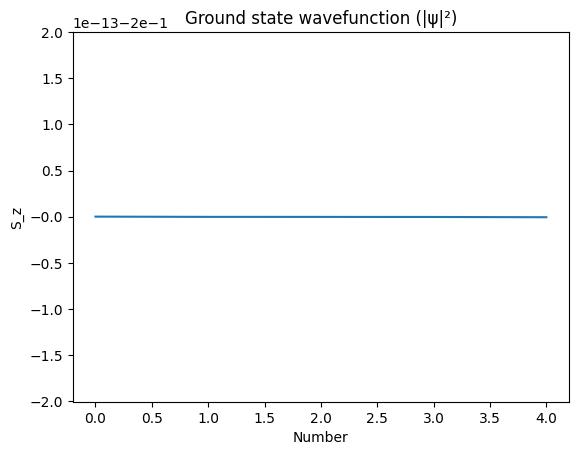

In [69]:
# Plot the wavefunction (amplitudes) of the ground state
index_to_state = {i: np.array([1 if bit == '1' else -1 for bit in bin(i)[2:].zfill(N)]) for i in range(2**N)}
ground_state = eigvecs[:, 0]
sz_plane = 0
for i in range(2**N):
    sz_plane += index_to_state[i] * np.abs(np.array(ground_state.T[0])**2)[0][i]
plt.figure()
plt.plot(sz_plane)
plt.xlabel('Number')
plt.ylabel('S_z')
plt.title('Ground state wavefunction (|ψ|²)')
plt.show()

In [64]:
index_to_state = {i: np.array([1 if bit == '1' else -1 for bit in bin(i)[2:].zfill(N)]) for i in range(2**N)}
index_to_state[5]

array([-1,  1, -1,  1])

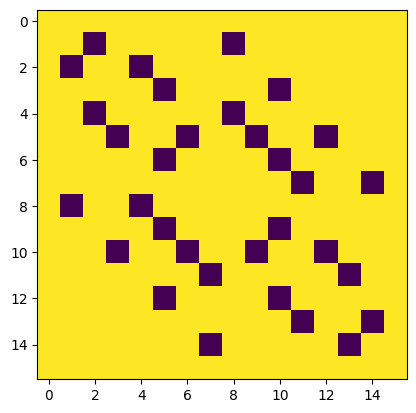

In [19]:
plt.imshow(H.real)

In [22]:
# Parameters
N = 4         # Number of spins
J = 1.0       # Coupling constant
h = 0.0       # Transverse field

# Example usage for fixed S_z sector
sz_value = 0  # total S_z = 0 (2 up, 2 down for N=4)

H_sz, basis_sz = xy_hamiltonian_fixed_sz(N, J, h, sz_value)
eigvals_sz, eigvecs_sz = np.linalg.eigh(H_sz)
print(f"\nEigenvalues (energies) in S_z = {sz_value} sector:")
print(eigvals_sz)
print("Minimal energy: ", min(eigvals_sz))

print(f"\nFull Hilbert space dimension: {2**N}")
print(f"Fixed S_z sector dimension: {len(basis_sz)}")


Eigenvalues (energies) in S_z = 0 sector:
[-5.65685425e+00 -3.88716888e-17  0.00000000e+00  0.00000000e+00
  0.00000000e+00  5.65685425e+00]
Minimal energy:  -5.65685424949238

Full Hilbert space dimension: 16
Fixed S_z sector dimension: 6


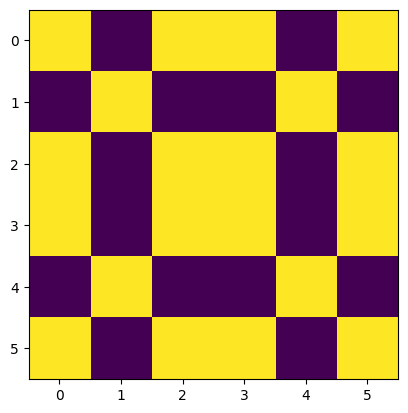

In [23]:
plt.imshow(H_sz.real)